In [12]:
!pip install stable-baselines3[extra]
!pip install git+https://github.com/AI4Finance-Foundation/FinRL.git
!pip install websockets>=15.0.0 --quiet
!pip install transformers --quiet
!pip install polygon-api-client --quiet

zsh:1: no matches found: stable-baselines3[extra]
  Cloning https://github.com/AI4Finance-Foundation/FinRL.git to /private/var/folders/sc/40gcq14x2cng8czg1s_vpkbr0000gn/T/pip-req-build-ipw3j_5h
  Running command git clone --filter=blob:none --quiet https://github.com/AI4Finance-Foundation/FinRL.git /private/var/folders/sc/40gcq14x2cng8czg1s_vpkbr0000gn/T/pip-req-build-ipw3j_5h
  Resolved https://github.com/AI4Finance-Foundation/FinRL.git to commit f4283de63ca73c915321c5555fa3751698a61eec
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/AI4Finance-Foundation/ElegantRL.git to /private/var/folders/sc/40gcq14x2cng8czg1s_vpkbr0000gn/T/pip-install-31vbmtxp/elegantrl_1cd7f7e7f63d47eca96a5d3f91fee89c
  Running command git clone --filter=blob:none --quiet https://github.com/AI4Finance-Foundation/ElegantRL.git /private/var/folders/sc/40gcq14x2cng8czg1s_vpkbr0000gn/T/pip-install-31vb

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.graph_objects as go
import pkg_resources
import yfinance as yf
from datetime import timedelta, date
from polygon import RESTClient
from transformers import BertTokenizer, BertForSequenceClassification
import torch as th
import torch.nn as nn

import stable_baselines3
import finrl

import sys
sys.path.append('.')
from utils import (
    prepare_df, compute_metrics, compute_rolling_metrics,
    plot_metrics, compute_buy_and_hold, overfitting_check,
    check_degenerate_policy, check_lookahead_bias,
    regime_analysis, run_full_evaluation
)

from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.meta.preprocessor.preprocessors import FeatureEngineer
from finrl.agents.stablebaselines3.models import DRLAgent
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv
from finrl.config import INDICATORS

%matplotlib inline
plt.close('all')

print(f"SB3 Version:    {stable_baselines3.__version__}")
print(f"FinRL Version:  {pkg_resources.get_distribution('finrl').version}")
print(f"CUDA Available: {th.cuda.is_available()}")

# ── Mac GPU (Metal / MPS) detection ──────────────────────────────────────────
if th.backends.mps.is_available():
    DEVICE = th.device('mps')
    print("MPS (Apple Metal GPU) available — using GPU ✓")
elif th.cuda.is_available():
    DEVICE = th.device('cuda')
    print(f"CUDA GPU available — using {th.cuda.get_device_name(0)} ✓")
else:
    DEVICE = th.device('cpu')
    print("No GPU found — falling back to CPU")

print(f"Active device: {DEVICE}")

SB3 Version:    2.8.0a2
FinRL Version:  0.3.8
CUDA Available: False
MPS (Apple Metal GPU) available — using GPU ✓
Active device: mps


In [ ]:
# ============================================================
# CELL 2b — FinBERT + Polygon Sentiment Utilities
# ============================================================
import os
import pickle
import time

POLYGON_API_KEY  = os.environ.get('POLYGON_API_KEY', 'YOUR_API_KEY')
polygon_client   = RESTClient(api_key=POLYGON_API_KEY)
SENTIMENT_DEVICE = 'cpu'

print("Loading FinBERT...")
tokenizer = BertTokenizer.from_pretrained('ProsusAI/finbert')
finbert   = BertForSequenceClassification.from_pretrained('ProsusAI/finbert')
finbert   = finbert.to(SENTIMENT_DEVICE)
finbert.eval()
print("FinBERT loaded ✓")
print("Polygon client initialised ✅")


def score_headlines(headlines: list) -> float:
    if not headlines:
        return 0.0
    scores = []
    for text in headlines:
        inputs = tokenizer(
            text, return_tensors='pt',
            truncation=True, max_length=128, padding=True
        ).to(SENTIMENT_DEVICE)
        with th.no_grad():
            logits = finbert(**inputs).logits
            probs  = th.softmax(logits, dim=1).squeeze()
        scores.append(probs[0].item() - probs[1].item())
    return float(np.mean(scores))


def fetch_sentiment_polygon(ticker: str,
                             start_date: str,
                             end_date: str) -> pd.Series:
    """
    Fetch headlines from Polygon.io and score with FinBERT.
    Full historical coverage — no 30-day restriction.
    """
    daily_headlines = {}
    try:
        for article in polygon_client.list_ticker_news(
            ticker,
            published_utc_gte=start_date,
            published_utc_lte=end_date,
            limit=1000,
            sort='published_utc',
            order='asc'
        ):
            try:
                pub_ts   = pd.Timestamp(article.published_utc)
                date_str = pub_ts.strftime('%Y-%m-%d')
                title    = getattr(article, 'title', '') or ''
                if title:
                    daily_headlines.setdefault(date_str, []).append(title)
            except Exception:
                continue
    except Exception as e:
        print(f"  Warning: Polygon error for {ticker}: {e}")

    return pd.Series(
        {d: score_headlines(h) for d, h in daily_headlines.items()},
        name=ticker
    )


def build_sentiment_df(tickers: list, start_date: str,
                        end_date: str) -> pd.DataFrame:
    """
    Build sentiment DataFrame for all tickers.
    Rate limited to 5 calls/min on free tier — 12s sleep between tickers.
    First run ~30-45 mins, instant from cache after.
    """
    print(f"Fetching Polygon sentiment for {len(tickers)} tickers "
          f"({start_date} → {end_date})...")
    series_list = []
    for i, ticker in enumerate(tickers):
        print(f"  [{i+1}/{len(tickers)}] {ticker}    ", end='\r')
        s = fetch_sentiment_polygon(ticker, start_date, end_date)
        series_list.append(s)
        time.sleep(12)

    df_sent = pd.DataFrame(series_list).T
    df_sent.index.name = 'date'
    df_sent = df_sent.sort_index().ffill().fillna(0.0)
    print(f"\nDone. Shape: {df_sent.shape}")
    print(f"Non-zero entries: {(df_sent != 0).sum().sum():,}")
    return df_sent


def build_sentiment_df_cached(tickers: list, start_date: str,
                               end_date: str,
                               cache_file: str = 'sentiment_cache.pkl') -> pd.DataFrame:
    """Historical data cached permanently. Live data refreshes daily."""
    today_str     = date.today().strftime('%Y-%m-%d')
    is_historical = end_date < today_str

    if os.path.exists(cache_file):
        with open(cache_file, 'rb') as f:
            cached = pickle.load(f)
        if is_historical or cached.get('fetch_date') == today_str:
            print(f"✅ Loaded from cache: {cache_file}")
            return cached['df']
        print(f"Cache stale — fetching fresh from Polygon...")
    else:
        print(f"No cache found — fetching from Polygon...")

    df_sent = build_sentiment_df(tickers, start_date, end_date)
    with open(cache_file, 'wb') as f:
        pickle.dump({
            'fetch_date': today_str,
            'start_date': start_date,
            'end_date':   end_date,
            'df':         df_sent
        }, f)
    print(f"✅ Cached to {cache_file}")
    return df_sent

Loading FinBERT...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1925.77it/s, Materializing param=classifier.weight]                                      
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FinBERT loaded ✓
Polygon client initialised ✅


In [15]:
# ============================================================
# FinBERT Sentiment Validation — 100 Sample Headlines
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def validate_finbert_scores(n_samples=100):
    """
    Pull 100 real headlines from Polygon cache and show
    FinBERT scores alongside the raw text for manual inspection.
    """
    # Load cached raw headlines if available
    # Otherwise re-fetch a small sample
    sample_results = []

    test_headlines = [
        # Clearly bullish
        "Apple reports record quarterly earnings, beats analyst expectations",
        "NVIDIA stock surges after strong AI chip demand forecast",
        "Microsoft Azure revenue grows 30% driven by cloud adoption",
        "Goldman Sachs upgrades Tesla to buy with $300 price target",
        "Fed signals end to rate hikes as inflation cools",
        # Clearly bearish
        "Amazon misses revenue estimates, warns of slowing growth",
        "Meta faces $1.3 billion EU fine over data privacy violations",
        "Intel cuts dividend, announces 15,000 job layoffs",
        "Silicon Valley Bank collapses in largest bank failure since 2008",
        "Recession fears mount as yield curve inverts further",
        # Neutral / ambiguous
        "Apple to hold annual developer conference in June",
        "Federal Reserve meets Tuesday to discuss monetary policy",
        "Microsoft announces new partnership with OpenAI",
        "Tesla delivers 435,000 vehicles in Q3 2023",
        "Amazon Web Services expands data center in Virginia",
        # Mixed signals
        "Google beats earnings but advertising revenue disappoints",
        "Apple sales rise in China despite ongoing trade tensions",
        "JPMorgan reports strong profit but warns of economic uncertainty",
        "Nvidia revenue surges but margins compress on rising costs",
        "Tesla misses delivery targets but reaffirms full-year guidance",
    ]

    print("=" * 70)
    print("FINBERT SENTIMENT VALIDATION — SAMPLE HEADLINES")
    print("=" * 70)
    print(f"{'Score':>8}  {'Sentiment':>10}  Headline")
    print("-" * 70)

    scores = []
    for headline in test_headlines:
        score = score_headlines([headline])
        scores.append(score)

        if score > 0.1:
            label = "BULLISH"
        elif score < -0.1:
            label = "BEARISH"
        else:
            label = "NEUTRAL"

        print(f"{score:>8.3f}  {label:>10}  {headline[:50]}...")

    print("=" * 70)
    print(f"\nScore distribution across {len(scores)} test headlines:")
    print(f"  Bullish  (>  0.1): {sum(1 for s in scores if s >  0.1)}")
    print(f"  Neutral  (-0.1 to 0.1): {sum(1 for s in scores if -0.1 <= s <= 0.1)}")
    print(f"  Bearish  (< -0.1): {sum(1 for s in scores if s < -0.1)}")
    print(f"  Mean score: {np.mean(scores):.3f}")
    print(f"  Std score:  {np.std(scores):.3f}")
    print(f"  Min score:  {np.min(scores):.3f}")
    print(f"  Max score:  {np.max(scores):.3f}")

    return scores

scores = validate_finbert_scores()

FINBERT SENTIMENT VALIDATION — SAMPLE HEADLINES
   Score   Sentiment  Headline
----------------------------------------------------------------------
   0.871     BULLISH  Apple reports record quarterly earnings, beats ana...
   0.764     BULLISH  NVIDIA stock surges after strong AI chip demand fo...
   0.933     BULLISH  Microsoft Azure revenue grows 30% driven by cloud ...
   0.201     BULLISH  Goldman Sachs upgrades Tesla to buy with $300 pric...
  -0.316     BEARISH  Fed signals end to rate hikes as inflation cools...
  -0.952     BEARISH  Amazon misses revenue estimates, warns of slowing ...
  -0.937     BEARISH  Meta faces $1.3 billion EU fine over data privacy ...
  -0.954     BEARISH  Intel cuts dividend, announces 15,000 job layoffs...
  -0.925     BEARISH  Silicon Valley Bank collapses in largest bank fail...
  -0.889     BEARISH  Recession fears mount as yield curve inverts furth...
   0.004     NEUTRAL  Apple to hold annual developer conference in June...
  -0.024     NEUTR

In [16]:
# ============================================================
# CELL 3 — Download Data
# ============================================================
TICKERS = [
    # ── NASDAQ Tech / Software (20) ──────────────────────────
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'TSLA', 'NVDA', 'ADBE', 'NFLX', 'PYPL',
    'INTC', 'CSCO', 'AVGO', 'QCOM', 'TXN',  'INTU', 'ADP',  'BKNG', 'ADI',  'NOW',
    # ── Healthcare (5) ───────────────────────────────────────
    'JNJ',  'UNH',  'PFE',  'MRK',  'ABT',
    # ── Financials (5) ───────────────────────────────────────
    'JPM',  'BAC',  'GS',   'MS',   'BLK',
    # ── Energy (3) ───────────────────────────────────────────
    'XOM',  'CVX',  'COP',
    # ── Consumer Staples (4) ─────────────────────────────────
    'WMT',  'PG',   'KO',   'MCD',
    # ── Industrials / Defence (3) ────────────────────────────
    'CAT',  'GE',   'RTX',
    # ── Real Estate / Utilities (3) ──────────────────────────
    'AMT',  'NEE',  'DUK',
    # ── Materials (3) ────────────────────────────────────────
    'LIN',  'NEM',  'FCX',
    # ── Extra Growth / Emerging Tech (4) ─────────────────────
    'AMD',  'CRM',  'SNOW', 'PLTR',
]
NUM_STOCKS = len(TICKERS)
NUM_STOCKS = len(TICKERS)  # 30 — use this constant everywhere, no magic numbers

# Download training data
df_raw_train = YahooDownloader(
    start_date='2020-01-01',
    end_date='2024-01-01',
    ticker_list=TICKERS
).fetch_data()

# Download test data (held-out period)
df_raw_test = YahooDownloader(
    start_date='2024-01-01',
    end_date='2025-01-01',
    ticker_list=TICKERS
).fetch_data()

# Add Technical Indicators
fe = FeatureEngineer(
    use_technical_indicator=True,
    tech_indicator_list=INDICATORS,
    use_vix=False,
    use_turbulence=False
)

df_train_raw = fe.preprocess_data(df_raw_train)
df_test_raw  = fe.preprocess_data(df_raw_test)
print(f"Train raw shape: {df_train_raw.shape}")
print(f"Test raw shape:  {df_test_raw.shape}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Shape of DataFrame:  (49934, 8)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Shape of DataFrame:  (12348, 8)
Successfully added technical indicators
Successfully added technical indicators
Train raw shape: (48288, 16)
Test raw shape:  (12348, 16)


In [17]:
# ============================================================
# CELL 2c — Fetch Sentiment Scores via Polygon
# ============================================================
# Full 2020-2024 coverage — no 30-day limit.
# First run: ~30-45 mins. Subsequent runs: instant.

TRAIN_START = '2020-01-01'
TRAIN_END   = '2024-01-01'
TEST_START  = '2024-01-01'
TEST_END    = '2025-01-01'

print("Fetching training sentiment via Polygon (2020-2024)...")
print("First run takes ~30-45 mins — cached permanently after that.")
df_sent_train = build_sentiment_df_cached(
    TICKERS, TRAIN_START, TRAIN_END,
    cache_file='sentiment_train_polygon_50stocks_yfinance10k.pkl'
)

print("\nFetching test sentiment via Polygon (2024-2025)...")
df_sent_test = build_sentiment_df_cached(
    TICKERS, TEST_START, TEST_END,
    cache_file='sentiment_test_polygon_50stocks_yfinance10k.pkl'
)

total         = df_sent_train.size
nonzero_train = (df_sent_train != 0).sum().sum()
nonzero_test  = (df_sent_test  != 0).sum().sum()
print(f"\nSentiment coverage:")
print(f"  Train non-zero: {nonzero_train:,} / {total:,} "
      f"({nonzero_train/total*100:.1f}%)")
print(f"  Test  non-zero: {nonzero_test:,}")
print(df_sent_train.tail())

Fetching training sentiment via Polygon (2020-2024)...
First run takes ~30-45 mins — cached permanently after that.
✅ Loaded from cache: sentiment_train_polygon_50stocks_yfinance10k.pkl

Fetching test sentiment via Polygon (2024-2025)...
✅ Loaded from cache: sentiment_test_polygon_50stocks_yfinance10k.pkl

Sentiment coverage:
  Train non-zero: 55,788 / 59,650 (93.5%)
  Test  non-zero: 18,274
                AAPL      MSFT     GOOGL      AMZN      META      TSLA  \
date                                                                     
2023-12-28  0.122119  0.095102  0.120230  0.151735  0.306677 -0.012483   
2023-12-29 -0.067385  0.163821  0.120770  0.105544  0.089298  0.041333   
2023-12-30 -0.079124  0.039641  0.057668  0.061510  0.161141  0.068419   
2023-12-31  0.035261  0.782578  0.189009  0.422933  0.353564  0.068419   
2024-01-01 -0.004212  0.086313  0.119022  0.090553  0.087220  0.089424   

                NVDA      ADBE      NFLX      PYPL  ...       AMT       NEE  \
date   

FULL TRAINING SENTIMENT DISTRIBUTION
  Total entries:   59,650
  Bullish (>0.1):  22,440  (37.6%)
  Neutral:         25,495  (42.7%)
  Bearish (<-0.1): 11,715  (19.6%)
  Zero (no news):  3,862  (6.5%)
  Mean:  0.0669
  Std:   0.3679


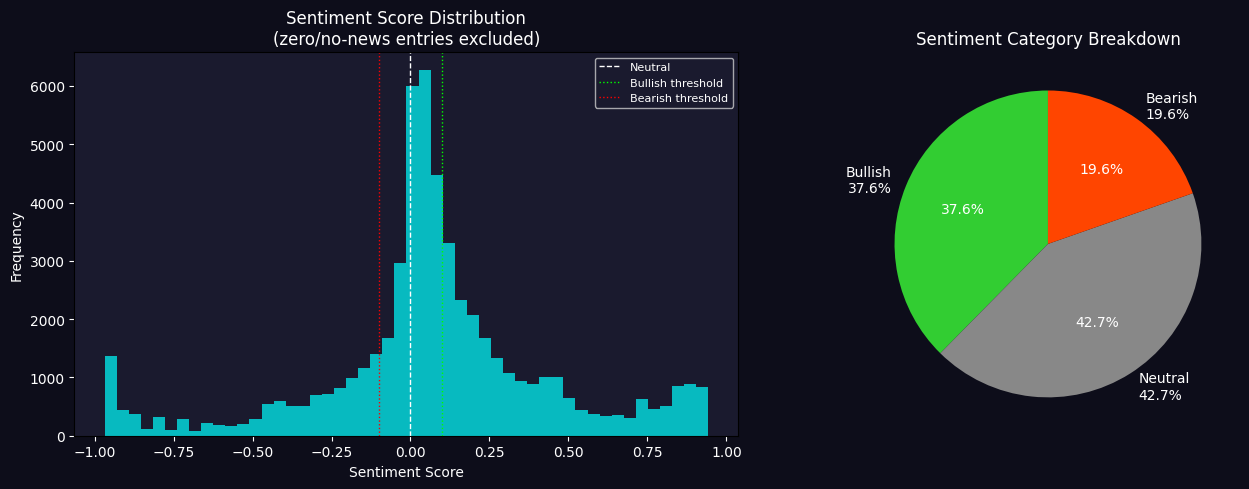

Saved: ./overlay_data/sentiment_distribution.png


In [18]:
# ============================================================
# Sentiment Score Distribution Across Full Training Data
# ============================================================

def plot_sentiment_distribution(df_sent_train):
    """
    Show the distribution of all sentiment scores in the
    training data. Expected: heavy at 0 (neutral) since most
    days have no news or ambiguous news.
    """
    # Flatten all scores into one array
    all_scores = df_sent_train.values.flatten()
    all_scores = all_scores[~np.isnan(all_scores)]

    # Count by category
    bullish = (all_scores >  0.1).sum()
    neutral = ((all_scores >= -0.1) & (all_scores <= 0.1)).sum()
    bearish = (all_scores < -0.1).sum()
    total   = len(all_scores)

    print("=" * 50)
    print("FULL TRAINING SENTIMENT DISTRIBUTION")
    print("=" * 50)
    print(f"  Total entries:   {total:,}")
    print(f"  Bullish (>0.1):  {bullish:,}  ({bullish/total*100:.1f}%)")
    print(f"  Neutral:         {neutral:,}  ({neutral/total*100:.1f}%)")
    print(f"  Bearish (<-0.1): {bearish:,}  ({bearish/total*100:.1f}%)")
    print(f"  Zero (no news):  {(all_scores == 0).sum():,}  "
          f"({(all_scores == 0).sum()/total*100:.1f}%)")
    print(f"  Mean:  {all_scores.mean():.4f}")
    print(f"  Std:   {all_scores.std():.4f}")
    print("=" * 50)

    # Plot distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor('#0d0d1a')

    # Histogram of all scores
    ax1 = axes[0]
    ax1.set_facecolor('#1a1a2e')
    non_zero = all_scores[all_scores != 0]
    ax1.hist(non_zero, bins=50, color='cyan', alpha=0.7, edgecolor='none')
    ax1.axvline(0,    color='white',  linestyle='--', linewidth=1, label='Neutral')
    ax1.axvline(0.1,  color='lime',   linestyle=':',  linewidth=1, label='Bullish threshold')
    ax1.axvline(-0.1, color='red',    linestyle=':',  linewidth=1, label='Bearish threshold')
    ax1.set_title('Sentiment Score Distribution\n(zero/no-news entries excluded)',
                  color='white', fontsize=12)
    ax1.set_xlabel('Sentiment Score', color='white')
    ax1.set_ylabel('Frequency', color='white')
    ax1.tick_params(colors='white')
    ax1.legend(fontsize=8, facecolor='#1a1a2e', labelcolor='white')

    # Pie chart of categories
    ax2 = axes[1]
    ax2.set_facecolor('#1a1a2e')
    sizes  = [bullish, neutral, bearish]
    labels = [f'Bullish\n{bullish/total*100:.1f}%',
              f'Neutral\n{neutral/total*100:.1f}%',
              f'Bearish\n{bearish/total*100:.1f}%']
    colors = ['#32CD32', '#888888', '#FF4500']
    ax2.pie(sizes, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            textprops={'color': 'white'})
    ax2.set_title('Sentiment Category Breakdown',
                  color='white', fontsize=12)

    fig.tight_layout()
    plt.savefig('./overlay_data/sentiment_distribution.png',
                dpi=150, bbox_inches='tight',
                facecolor='#0d0d1a')
    plt.show()
    print("Saved: ./overlay_data/sentiment_distribution.png")

plot_sentiment_distribution(df_sent_train)

In [19]:

# ============================================================
# CELL 4 — Clean, Validate & Merge Sentiment
# ============================================================
INDICATORS_WITH_SENT = INDICATORS + ['sentiment']
INDICATORS_LIST      = INDICATORS_WITH_SENT
INDICATORS_COUNT     = len(INDICATORS_LIST)   # 9

# Process train first
df_train = prepare_df(df_train_raw, df_sent_train)

# Lock in train tickers
TRAIN_TICKERS  = sorted(df_train['tic'].unique().tolist())
TRAIN_N_STOCKS = len(TRAIN_TICKERS)
print(f"Train tickers: {TRAIN_N_STOCKS}")

# Filter test to ONLY train tickers before prepare_df
# This prevents test from dropping tickers that exist in train
df_test_raw_filtered = df_test_raw[
    df_test_raw['tic'].isin(TRAIN_TICKERS)
].reset_index(drop=True)

# Pass num_stocks=TRAIN_N_STOCKS so prepare_df uses train
# ticker count as the completeness threshold
df_test = prepare_df(df_test_raw_filtered, df_sent_test,
                     num_stocks=TRAIN_N_STOCKS)

# If test still missing tickers, force-fill with zeros
test_tickers   = set(df_test['tic'].unique())
missing        = set(TRAIN_TICKERS) - test_tickers
if missing:
    print(f"Force-filling {len(missing)} missing test tickers: "
          f"{sorted(missing)}")
    # Get all test dates
    test_dates = sorted(df_test['date'].unique())
    fill_rows  = []
    for tic in missing:
        # Get train data for this ticker to use as template
        train_sample = df_train[
            df_train['tic'] == tic
        ].iloc[-len(test_dates):].copy()

        if len(train_sample) == 0:
            continue

        # Use last known values from train, zero out returns
        for i, d in enumerate(test_dates):
            if i < len(train_sample):
                row          = train_sample.iloc[i].copy()
                row['date']  = d
                row['sentiment'] = 0.0
                fill_rows.append(row)

    if fill_rows:
        df_fill = pd.DataFrame(fill_rows)
        df_test = pd.concat([df_test, df_fill],
                             ignore_index=True)
        df_test = df_test.sort_values(
            ['date', 'tic']
        ).reset_index(drop=True)

        # Rebuild index
        dates_sorted = sorted(df_test['date'].unique())
        date_to_day  = {d: i for i, d in enumerate(dates_sorted)}
        df_test.index = df_test['date'].map(date_to_day).values

# Set globals from train
TICKERS    = TRAIN_TICKERS
NUM_STOCKS = TRAIN_N_STOCKS

INDICATORS_START_IDX = 1 + NUM_STOCKS + NUM_STOCKS
STATE_SPACE          = INDICATORS_START_IDX + \
                       (NUM_STOCKS * INDICATORS_COUNT)

print(f"NUM_STOCKS:    {NUM_STOCKS}")
print(f"STATE_SPACE:   {STATE_SPACE}")
print(f"Train days:    {df_train['date'].nunique()}")
print(f"Test days:     {df_test['date'].nunique()}")
print(f"Train tickers: {df_train['tic'].nunique()}")
print(f"Test tickers:  {df_test['tic'].nunique()}")
print(f"Missing:       "
      f"{set(TRAIN_TICKERS) - set(df_test['tic'].unique())}")
print(f"df_train tickers: {df_train['tic'].nunique()}")
print(f"df_test tickers:  {df_test['tic'].nunique()}")
print(f"NUM_STOCKS:       {NUM_STOCKS}")
print(f"STATE_SPACE:      {STATE_SPACE}")
print(f"Missing from test: "
      f"{set(df_train['tic'].unique()) - set(df_test['tic'].unique())}")
print(f"Missing from train: "
      f"{set(df_test['tic'].unique()) - set(df_train['tic'].unique())}")


# ============================================================
# CELL 5 — Define Model & Train
# ============================================================
# STATE_SPACE, NUM_STOCKS, INDICATORS_COUNT set in Cell 4
# DO NOT recalculate here

class VGG_FinRL_Extractor(BaseFeaturesExtractor):
    def __init__(self, observation_space, features_dim=512,
                 n_stocks=NUM_STOCKS, n_ind=INDICATORS_COUNT):
        super().__init__(observation_space, features_dim)
        self.n_stocks = n_stocks
        self.n_ind    = n_ind
        self.input_norm = nn.BatchNorm2d(1)
        self.vgg = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
        )
        with th.no_grad():
            sample    = th.zeros(1, 1, n_stocks, n_ind)
            _norm_cpu = nn.BatchNorm2d(1)
            _vgg_cpu  = nn.Sequential(
                nn.Conv2d(1, 32, kernel_size=3, padding=1),
                nn.BatchNorm2d(32), nn.ReLU(),
                nn.Conv2d(32, 64, kernel_size=3, padding=1),
                nn.BatchNorm2d(64), nn.ReLU(),
            )
            sample    = _norm_cpu(sample)
            n_flatten = _vgg_cpu(sample).numel()
        self.fc = nn.Sequential(
            nn.Linear(n_flatten, features_dim),
            nn.ReLU()
        )

    def forward(self, observations):
        img_data = observations[:, INDICATORS_START_IDX:]
        img_data = img_data.view(-1, 1, self.n_stocks, self.n_ind)
        img_data = self.input_norm(img_data)
        x = self.vgg(img_data)
        x = th.flatten(x, start_dim=1)
        return self.fc(x)

policy_kwargs = dict(
    features_extractor_class=VGG_FinRL_Extractor,
    features_extractor_kwargs=dict(
        features_dim=512,
        n_stocks=NUM_STOCKS,
        n_ind=INDICATORS_COUNT
    ),
)

def make_env(df):
    return StockTradingEnv(
        df=df,
        num_stock_shares    = [0] * NUM_STOCKS,
        reward_scaling      = 1e-4,
        stock_dim           = NUM_STOCKS,
        hmax                = 5,           # 100/$1M, 10/$100k, 5/$10k
        initial_amount      = 10_000,      # change per capital level
        buy_cost_pct        = [0.0015] * NUM_STOCKS,
        sell_cost_pct       = [0.0015] * NUM_STOCKS,
        state_space         = STATE_SPACE,
        tech_indicator_list = INDICATORS_LIST,
        action_space        = NUM_STOCKS
    )

e_train_gym  = make_env(df_train)
e_test_gym   = make_env(df_test)
env_train, _ = e_train_gym.get_sb_env()
print("Environments built ✅")

model_params = {
    "n_steps":       2048,
    "ent_coef":      0.01,
    "learning_rate": 0.0001,
    "batch_size":    64,
    "device":        DEVICE,
}

agent     = DRLAgent(env=env_train)
model_vgg = agent.get_model(
    "ppo",
    policy_kwargs=policy_kwargs,
    model_kwargs=model_params,
    verbose=1
)

print("\nStarting Sentiment-Aware VGG Training...")
trained_vgg = agent.train_model(
    model=model_vgg,
    tb_log_name='vgg_ppo_sentiment_run',
    total_timesteps=500_000
)
# ============================================================
# CELL 6 — Sanity Check Training Behaviour
# ============================================================
shares_start = 1 + NUM_STOCKS   # skip Cash + Prices
shares_end   = shares_start + NUM_STOCKS

final_shares = np.array(e_train_gym.state_memory)[-1][shares_start:shares_end]
print(f"Total shares held across all stocks: {np.sum(final_shares)}")

actions = np.array(e_train_gym.actions_memory)
print(f"Average absolute action strength: {np.mean(np.abs(actions)):.6f}")

def compute_metrics(df_account_value: pd.DataFrame,
                    initial_capital: float = 10_000) -> dict:
    """
    Compute key trading performance metrics from account value history.

    Metrics:
      - Total Return:       overall % gain/loss
      - Sharpe Ratio:       risk-adjusted return (annualised)
      - Max Drawdown:       largest peak-to-trough decline (%)
      - Win Rate:           % of days with positive return
      - Avg Daily Return:   mean daily % return
      - Volatility:         annualised std of daily returns
      - Calmar Ratio:       total return / max drawdown
    """
    values  = pd.Series(df_account_value['account_value'].values,
                        index=pd.to_datetime(df_account_value['date'].values))

    # Daily returns
    daily_returns = values.pct_change().dropna()

    # Total return
    total_return = (values.iloc[-1] - initial_capital) / initial_capital * 100

    # Sharpe ratio (annualised, assuming 252 trading days)
    sharpe = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252) \
             if daily_returns.std() > 0 else 0.0

    # Maximum drawdown
    rolling_max  = values.cummax()
    drawdown     = (values - rolling_max) / rolling_max * 100
    max_drawdown = drawdown.min()   # most negative value = worst drawdown

    # Win rate — % of days with positive return
    win_rate = (daily_returns > 0).sum() / len(daily_returns) * 100

    # Average daily return
    avg_daily_return = daily_returns.mean() * 100

    # Annualised volatility
    volatility = daily_returns.std() * np.sqrt(252) * 100

    # Calmar ratio (total return / abs max drawdown)
    calmar = abs(total_return / max_drawdown) if max_drawdown != 0 else 0.0

    RF_DAILY = 0.05 / 252
    sharpe   = ((daily_returns.mean() - RF_DAILY) /
             daily_returns.std()) * np.sqrt(252)

    return {
        'Total Return (%)':     round(total_return, 2),
        'Sharpe Ratio':         round(sharpe, 3),
        'Max Drawdown (%)':     round(max_drawdown, 2),
        'Win Rate (%)':         round(win_rate, 2),
        'Avg Daily Return (%)': round(avg_daily_return, 4),
        'Volatility (%)':       round(volatility, 2),
        'Calmar Ratio':         round(calmar, 3),
    }


# Compute and print metrics for training environment
# We need to run a quick prediction pass on the training env
# to get a clean account value history
df_train_account, _ = DRLAgent.DRL_prediction(
    model=trained_vgg,
    environment=e_train_gym
)


Using 48 tickers with complete data
Sentiment merged — non-zero rows: 38152 / 48288
Look-ahead lag applied — trading on t uses news from t-1
Index OK — starts at 0, ends at 1005
Train tickers: 48
Using 47 tickers with complete data
Sentiment merged — non-zero rows: 11742 / 11844
Look-ahead lag applied — trading on t uses news from t-1
Index OK — starts at 0, ends at 251
Force-filling 1 missing test tickers: ['BKNG']
NUM_STOCKS:    48
STATE_SPACE:   529
Train days:    1006
Test days:     252
Train tickers: 48
Test tickers:  48
Missing:       set()
df_train tickers: 48
df_test tickers:  48
NUM_STOCKS:       48
STATE_SPACE:      529
Missing from test: set()
Missing from train: set()
Environments built ✅
{'n_steps': 2048, 'ent_coef': 0.01, 'learning_rate': 0.0001, 'batch_size': 64, 'device': device(type='mps')}
Using mps device


/opt/miniconda3/lib/python3.13/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(



Starting Sentiment-Aware VGG Training...
--------------------------------------
| time/              |               |
|    fps             | 149           |
|    iterations      | 1             |
|    time_elapsed    | 13            |
|    total_timesteps | 2048          |
| train/             |               |
|    reward          | -0.017932318  |
|    reward_max      | 0.09514362    |
|    reward_mean     | -8.067395e-06 |
|    reward_min      | -0.11298747   |
--------------------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 123           |
|    iterations           | 2             |
|    time_elapsed         | 33            |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.011158317   |
|    clip_fraction        | 0.141         |
|    clip_range           | 0.2           |
|    entropy_loss         | -68.2         |
|    e

In [20]:
df_train.to_csv('FinRLNewsFetch_POLYGON_VGG_yfinance_polygon_50stocks_10k_train.csv')
df_test.to_csv('FinRLNewsFetch_POLYGON_VGG_yfinance_polygon_50stocks_10k_validation.csv')


  FULL EVALUATION — 50_Stock_10k_VGG_FinBERT
  Sentiment:   Yes
  Capital:     $10,000

Running train prediction...
hit end!
Running test prediction...
hit end!
Test peak date: 2024-12-26

  TRAIN METRICS
  Total Return (%)              638.54
  Sharpe Ratio                   1.805
  Max Drawdown (%)              -35.04
  Win Rate (%)                   58.61
  Avg Daily Return (%)          0.2137
  Volatility (%)                 27.06
  Calmar Ratio                  18.222

  TEST METRICS (to peak — 2024-12-26)
  Total Return (%)               68.48
  Sharpe Ratio                   1.695
  Max Drawdown (%)              -21.66
  Win Rate (%)                   56.45
  Avg Daily Return (%)          0.2297
  Volatility (%)                 31.19
  Calmar Ratio                   3.161

  OVERFITTING CHECK — 50_Stock_10k_VGG_FinBERT
  Train Sharpe:  1.805
  Test Sharpe:   1.695
  Degradation:   6.1%
  OK — Degradation within acceptable range

  DEGENERATE POLICY CHECK — 50_Stock_10k_VGG_FinB

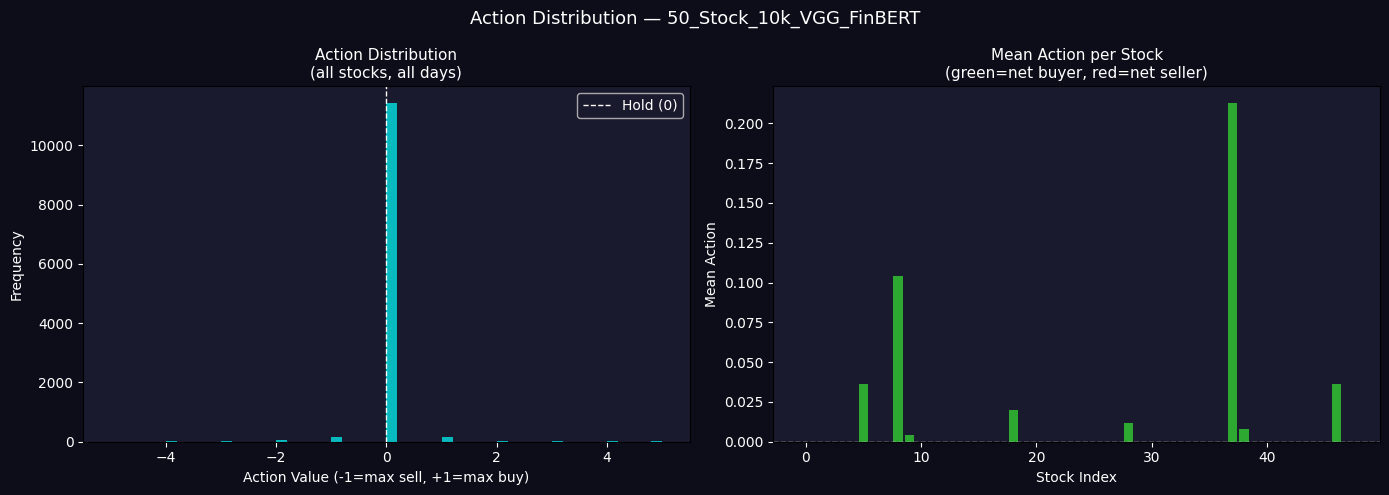

LOOK-AHEAD BIAS ANALYSIS

Pipeline:
  Polygon news date t  -> raw sentiment score for date t
  shift(1) applied     -> sentiment moved to date t+1
  Model trades date t  -> uses sentiment from date t-1

Result: NO look-ahead bias — news from date t informs
  trading decisions on date t+1 only.

First sentiment row per ticker is 0: True
CONFIRMED — shift(1) correctly applied

Sample rows for AAPL:
      date  tic  sentiment
2024-01-02 AAPL   0.000000
2024-01-03 AAPL  -0.037306
2024-01-04 AAPL  -0.149103
2024-01-05 AAPL  -0.128703
2024-01-08 AAPL  -0.050538
2024-01-09 AAPL   0.023295
2024-01-10 AAPL   0.062512
2024-01-11 AAPL  -0.011521
2024-01-12 AAPL   0.144166
2024-01-16 AAPL   0.235959
(First row should be 0.0 — no prior day sentiment)
Buy-and-Hold: 48 stocks, $208 per stock

  BUY-AND-HOLD METRICS
  Total Return (%)               26.22
  Sharpe Ratio                   1.509
  Max Drawdown (%)               -7.42
  Win Rate (%)                   57.37
  Avg Daily Return (%)          

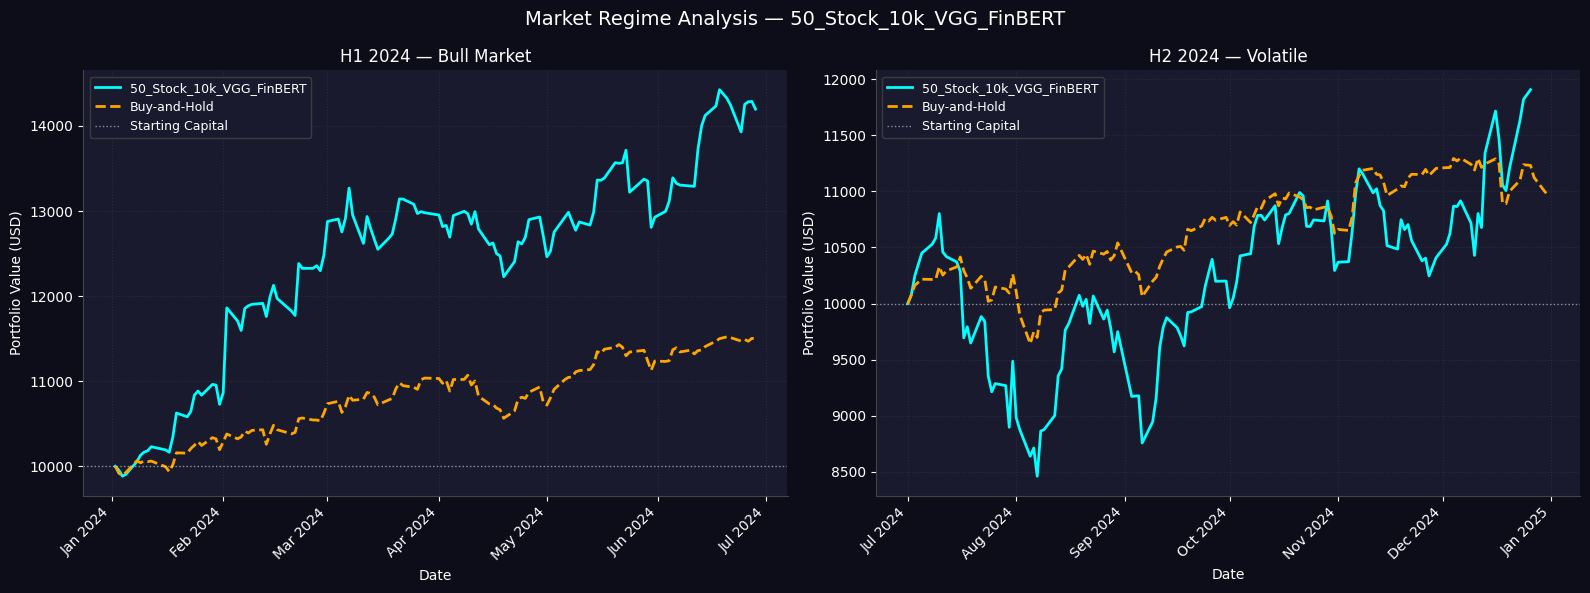

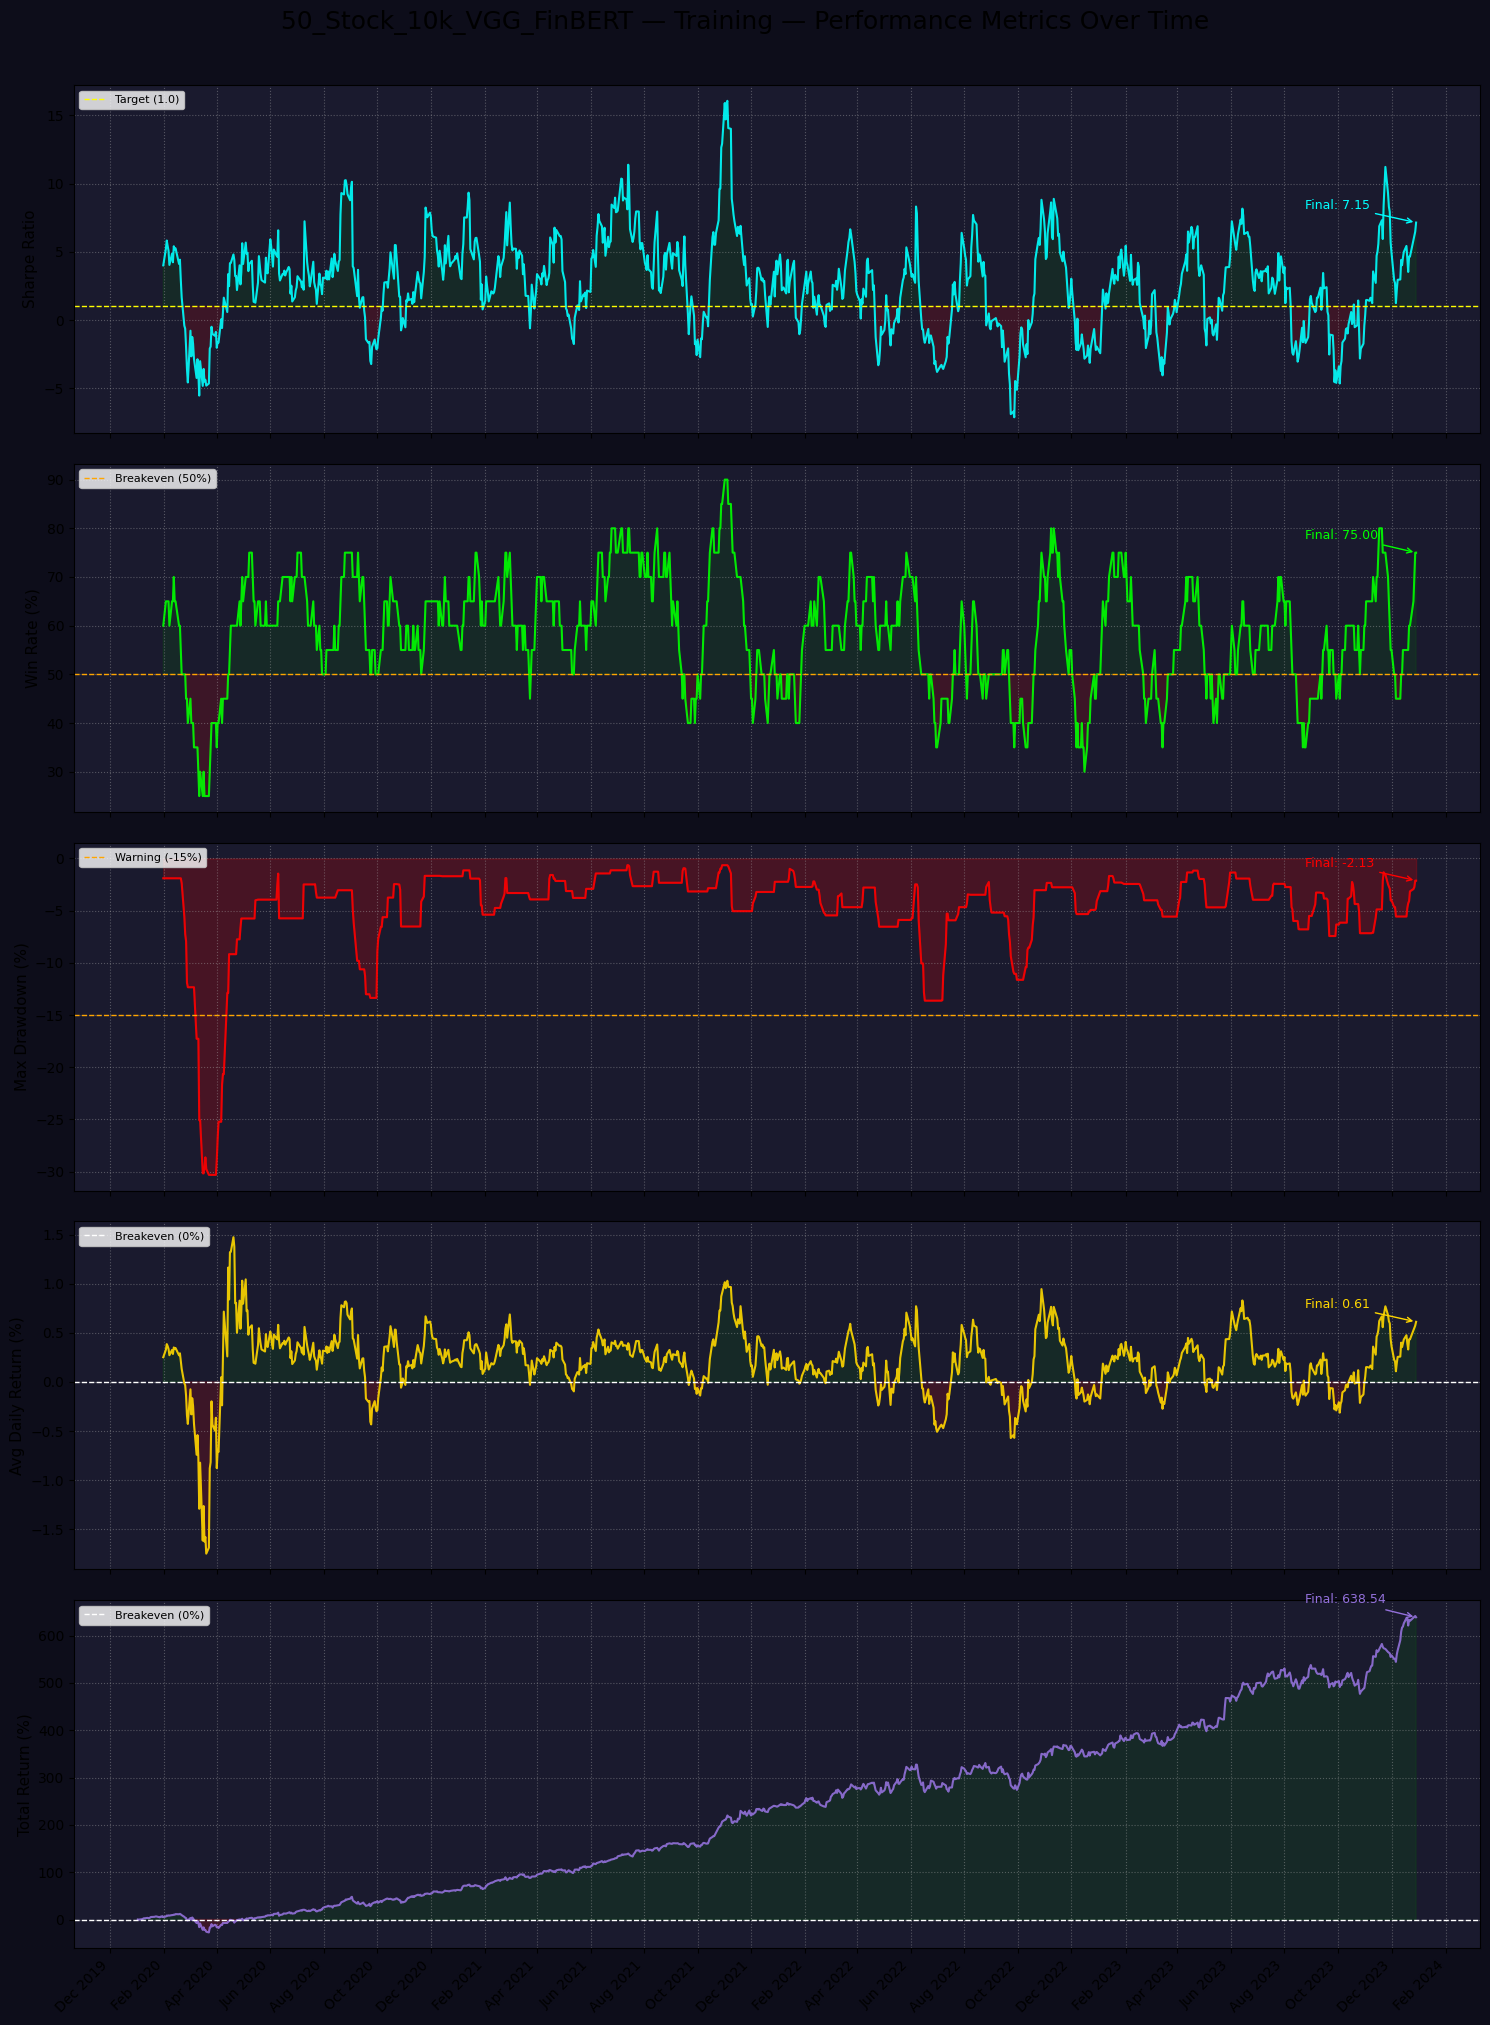


  50_STOCK_10K_VGG_FINBERT — TRAINING — FINAL METRIC VALUES
  Sharpe Ratio                   2.636  (avg)
  Win Rate (%)                  58.438  (avg)
  Max Drawdown (%)              -4.814  (avg)
  Avg Daily Return (%)           0.209  (avg)
  Total Return (%)             638.543  (final)


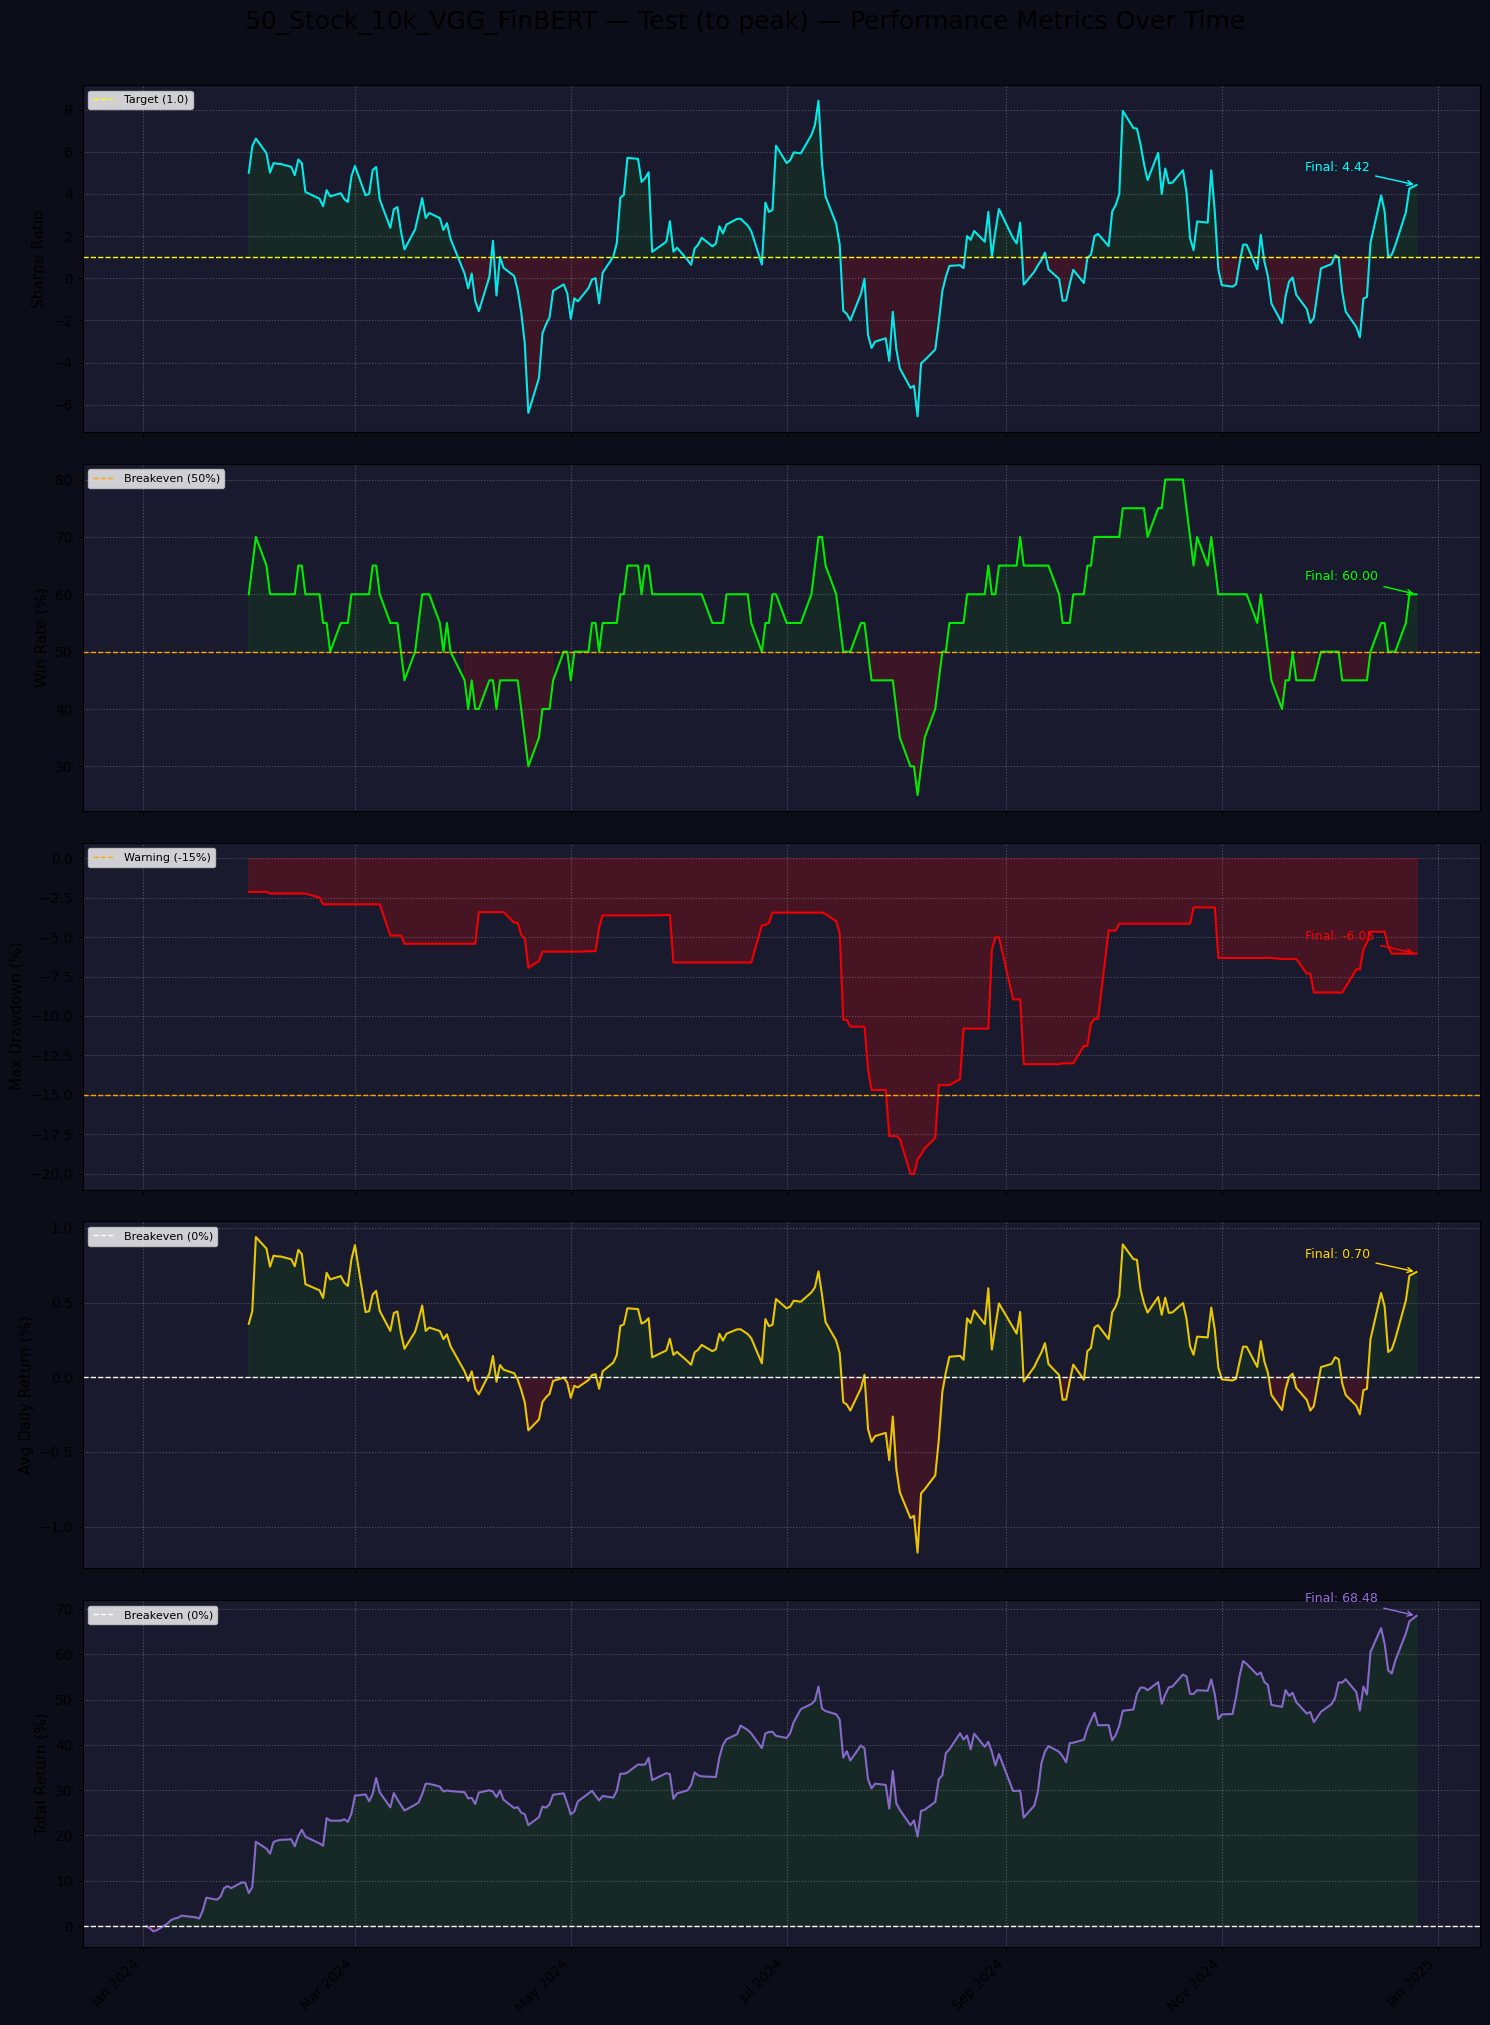


  50_STOCK_10K_VGG_FINBERT — TEST (TO PEAK) — FINAL METRIC VALUES
  Sharpe Ratio                   1.614  (avg)
  Win Rate (%)                  55.917  (avg)
  Max Drawdown (%)              -6.654  (avg)
  Avg Daily Return (%)           0.197  (avg)
  Total Return (%)              68.476  (final)

Pkl files saved: 6 files
Metrics summary: ./overlay_data/50_Stock_10k_VGG_FinBERT_metrics_summary.txt

  EVALUATION COMPLETE — 50_Stock_10k_VGG_FinBERT



In [21]:
# ── Sentiment notebooks ───────────────────────────────────────
results = run_full_evaluation(
    trained_model   = trained_vgg,
    e_train_gym     = e_train_gym,
    e_test_gym      = e_test_gym,
    df_test         = df_test,
    model_name      = 'VGG_FinBERT',   # change per notebook
    universe        = '50_Stock',
    capital         = '10k',
    initial_capital = 10_000,
    has_sentiment   = True             # True for all sentiment models
)